# 03 — Faithfulness Evaluation Harness

This notebook builds the machinery for the central question of the thesis: **when an
explainability method says "the model relied on *this* part of the signal," is that true?**
That property is called **faithfulness**, and measuring it needs a small pipeline of pieces
that fit together. We build that pipeline in **6 layers**, one at a time, so each piece can be
understood and sanity-checked on its own before the next depends on it:

1. **Region grid** — how the signal is divided into regions *(this notebook section)*
2. Perturbation — how a region is masked/removed
3. Deletion (and insertion) curves — how confidence moves as regions are removed
4. XAI relevance on the grid — TimeSHAP / IG / attention scores per region
5. CMI — the faithfulness score combining the above
6. Cross-model comparison — the same metric across Models 1–5

> This notebook section is **Layer 1 only**. No perturbation, deletion curves, CMI, or XAI
> code appears here yet — those are later layers.

## Layer 1 — The region grid

**What it is.** The ECG200 signal is 96 timesteps long. Rather than reason about every single
timestep in isolation, we chop the signal into a handful of contiguous **regions** — small
consecutive chunks of the timeline — and reason about whole regions. The **region grid** is
simply the rule that says *which timesteps belong to which region*.

**Why it must be the single source of truth.** Two different parts of the harness use the grid,
and they have to agree perfectly:

- the **XAI methods** (Layer 4) will report how much relevance each *region* received, and
- **CMI** (Layer 5) will *perturb* the signal one *region* at a time and watch the model.

If those two sides ever divided the signal even slightly differently — say one used regions of
size 4 where the other used size 5 — then "the relevance of region 7" and "the region 7 we
perturbed" would refer to different timesteps, and every faithfulness number downstream would
be silently wrong. So the grid is defined in exactly **one place**, `src/xai/regions.py`, and
everything imports it. This notebook never re-defines it; it only imports and inspects it.

**Region size (data-justified for ECG200).** Region size is set as a **percentage of the signal
length**, and we use two: **10% (primary — the data-justified anchor)** and **5% (secondary —
the fine grid)**. These sizes come from ECG200's *own* structure: the autocorrelation analysis
in [`01b_signal_scale_analysis`](01b_signal_scale_analysis.ipynb) found the signal's natural
correlation length is **~10 timesteps**, so a 10% region (≈9.6 ts) is about one coherent unit of
signal, and a 5% region (≈4.8 ts) is a finer resolution that still stays above the correlation
length. (An earlier draft inherited Šimić et al.'s 2.5% for the fine grid; we moved away from it
because on this short 96-point signal 2.5% is only ~2–3 timesteps — well below the natural scale,
so it fragments features. See `DECISIONS_LOG.md`.) Both sizes are exposed as named constants so
the whole harness shares one definition.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.data.preprocessing import load_ecg200
from src.xai.regions import (
    build_region_grid,
    describe_grid,
    REGION_SIZES,
    REGION_SIZE_PRIMARY_PCT,
    REGION_SIZE_SECONDARY_PCT,
)

SIGNAL_LENGTH = 96  # ECG200

grid_primary   = build_region_grid(SIGNAL_LENGTH, REGION_SIZE_PRIMARY_PCT)    # 10% — anchor
grid_secondary = build_region_grid(SIGNAL_LENGTH, REGION_SIZE_SECONDARY_PCT)  # 5%  — fine grid

print("region sizes in use:", REGION_SIZES)

region sizes in use: {'primary': 10.0, 'secondary': 5.0}


### The actual regions for a length-96 signal

`describe_grid` reports how many regions each size produces and the exact region lengths — the
sanity check that the partition is what we intend. Look for: full coverage (region sizes sum to
96), and region sizes that differ by at most 1.

In [2]:
for name, grid in [("primary (10%)", grid_primary), ("secondary (5%)", grid_secondary)]:
    d = describe_grid(grid)
    print(f"=== {name} ===")
    print(f"  n_regions      : {d['n_regions']}")
    print(f"  region sizes   : {d['size_counts']}  (size: how many regions)")
    print(f"  min/max/mean   : {d['min_size']} / {d['max_size']} / {d['mean_size']:.2f}")
    print(f"  total coverage : {d['total_coverage']}  (covers full signal: {d['covers_fully']})")
    print(f"  first 3 bounds : {grid.bounds[:3].tolist()}  ...  last: {grid.bounds[-1].tolist()}")
    print()

=== primary (10%) ===
  n_regions      : 10
  region sizes   : {9: 4, 10: 6}  (size: how many regions)
  min/max/mean   : 9 / 10 / 9.60
  total coverage : 96  (covers full signal: True)
  first 3 bounds : [[0, 10], [10, 20], [20, 30]]  ...  last: [87, 96]

=== secondary (5%) ===
  n_regions      : 20
  region sizes   : {4: 4, 5: 16}  (size: how many regions)
  min/max/mean   : 4 / 5 / 4.80
  total coverage : 96  (covers full signal: True)
  first 3 bounds : [[0, 5], [5, 10], [10, 15]]  ...  last: [92, 96]



### Seeing the grid on a real signal

Below is one example ECG200 beat with the region boundaries drawn as vertical lines — the fine
5% grid on top, the coarse 10% anchor below. This makes concrete how the same signal gets
chunked at the two resolutions: many narrow regions vs. a few wide ones.

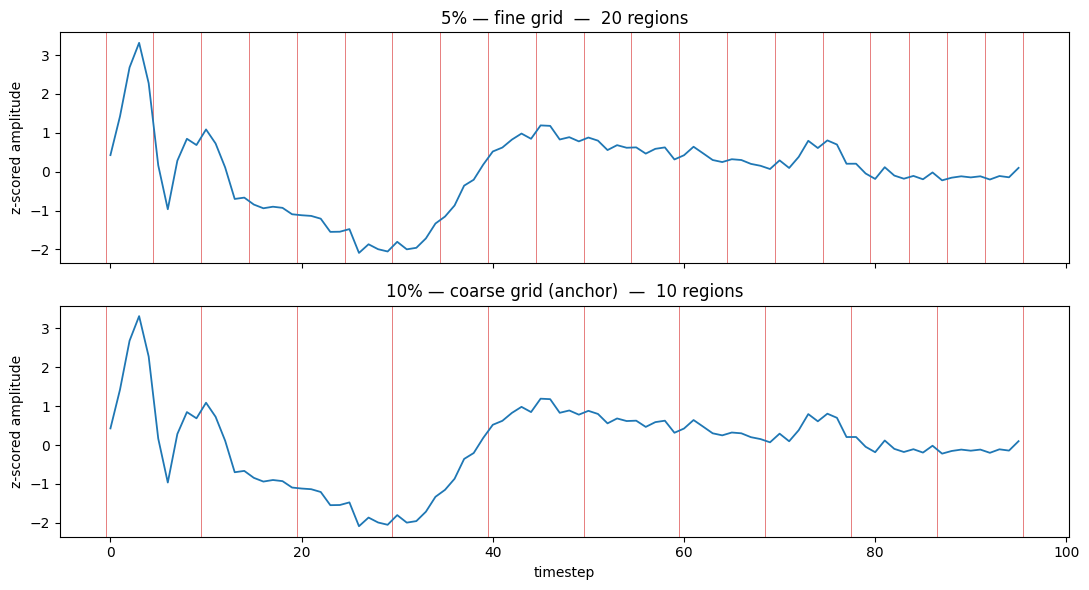

In [3]:
X_test, _ = load_ecg200("test")
signal = X_test[0]                      # one example beat
t = np.arange(SIGNAL_LENGTH)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for ax, (name, grid) in zip(axes, [("5% — fine grid", grid_secondary),
                                    ("10% — coarse grid (anchor)", grid_primary)]):
    ax.plot(t, signal, color="C0", linewidth=1.3, zorder=3)
    # Region boundaries: the start of every region, plus the final end.
    boundaries = np.append(grid.bounds[:, 0], grid.bounds[-1, 1])
    for b in boundaries:
        ax.axvline(b - 0.5, color="C3", linewidth=0.7, alpha=0.6, zorder=1)
    ax.set_title(f"{name}  —  {grid.n_regions} regions")
    ax.set_ylabel("z-scored amplitude")
axes[-1].set_xlabel("timestep")
fig.tight_layout()

FIG_DIR = PROJECT_ROOT / "results" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "03_region_grid.png", dpi=150, bbox_inches="tight")
plt.show()

### What the grid gives us (and the non-integer note)

For the length-96 ECG200 signal:

- **Primary, 10% → 10 regions**, with sizes **9 or 10** (4 regions of size 9, 6 of size 10). This
  is the data-justified anchor: ≈ the signal's ~10-timestep autocorrelation length, so each
  region is about one coherent unit of signal.
- **Secondary, 5% → 20 regions**, with sizes **4 or 5** (4 regions of size 4, 16 of size 5). This
  is the fine grid — higher resolution, but still above the correlation length rather than
  fragmenting features (which is why we moved off 2.5%; see below).

**Why the regions are not all the same width.** A percentage of 96 is usually not a whole number
of timesteps: **5% of 96 is 4.8 timesteps**, not an integer, so regions *cannot* all be the same
size. We handle this deliberately with a **count-based near-equal split**: we fix the number of
regions at `round(100 / pct)` — 10 for 10%, 20 for 5% — and divide the 96 timesteps into that
many contiguous regions as evenly as possible, distributing the remainder so region sizes differ
by **at most 1**. The **realized average region size is exactly 4.8** timesteps (96 / 20),
faithful to the intended 5%; the individual regions are simply 4 or 5 timesteps to make that
average work out over whole timesteps. The 10% grid is analogous: an average of 9.6 timesteps,
realized as regions of 9 or 10.

The alternative — rounding the *region length* to a whole number — was rejected because it drifts
away from the target percentage. This drift is most severe for small percentages on a short
signal, which is exactly the reason **2.5% was rejected for ECG200**: 2.5% of 96 is 2.4, which
would round to 2–3-timestep regions sitting well below the ~10-timestep natural scale. Fixing the
count keeps every region as close to its target percentage as whole timesteps allow, tiles the
whole signal with no gaps or overlaps, and is **deterministic**: the same `(length,
region_size_pct)` always returns the identical grid, so the XAI side and the CMI side are
guaranteed to share it.


## Layer 2 — Region perturbation and the three perturbation methods (PMs)

**What perturbation is.** To test whether a region matters to the model, we "hide" it and see if
the prediction changes. But a neural network needs a value at *every* timestep — you cannot pass
it a signal with a hole punched out. So **hiding a region means overwriting it with something
uninformative** (a *perturbation method*, PM) rather than deleting it. This is the covering-up
mechanism the later layers use: hide the regions an explanation calls important, and measure how
far the prediction moves.

**Why three methods, not one.** Every replacement value has side effects. Filling with zeros
injects a sharp artificial edge; filling with a flat value erases local shape; a
curvature (second-derivative) transform collapses smooth structure toward zero. Any *single* PM can therefore reward or punish an explanation for the
wrong reason — an artefact of that PM, not real reliance. Following Šimić, Veas & Sabol (2025,
Table 4) we use **three** PMs and later check that conclusions hold across all of them:

- **Zero** — replace the region with 0.
- **SampleMean** — replace the region with the mean of *this* signal (sample-level, not a
  training-set mean).
- **Laplace** — replace the region with its **second-derivative (Laplacian) transform** — an
  edge/curvature operator, *not* a smoother (adapted from the authors' code; see note below).

This layer consumes the **region grid from Layer 1** — the region being perturbed is a grid
region, identified by its index; this layer never redefines any boundaries. The logic lives in
`src/xai/perturbation.py` and is **dataset-agnostic**: signal length is read from the grid, no
class count is assumed, so it applies unchanged to a longer, multi-class signal later.

> ⚠️ **Laplace = the authors' actual operator, not smoothing.** Table 4 only names "Laplace" and
> its behaviour was ambiguous, so we define this PM by the authors' own source code, which is
> authoritative: it is `scipy.ndimage.laplace`, i.e. convolution with the discrete Laplacian
> **`[1, -2, 1]`** second-derivative kernel with reflect boundaries. This highlights where the
> signal *bends sharply* and sends smooth stretches toward ~0. (An earlier version of this
> notebook wrongly implemented Laplace as double-exponential *smoothing*; it was corrected after
> inspecting the reference repo — Apache 2.0, cited in `NOTICE` and `DECISIONS_LOG.md`.)

### Perturbing the QRS region three ways

We take one example ECG200 beat, find the region containing its strongest deflection (the
QRS-like trough — located data-drivenly as the signal's minimum, not a hard-coded index), and
perturb that one region with each PM. We use the **10% grid** so the region is wide enough (~10
timesteps) to clearly cover the feature.

In [4]:
from src.xai.perturbation import perturb_region, PERTURBATION_METHODS

# Reuse the example signal and the 10% grid built in Layer 1.
qrs_t = int(signal.argmin())            # strongest deflection ≈ QRS trough (data-driven)
qrs_region = int(grid_primary.labels[qrs_t])
r_start, r_stop = grid_primary.bounds[qrs_region]
print(f"QRS trough at timestep {qrs_t} -> grid region {qrs_region} "
      f"covering [{r_start}, {r_stop}) (size {r_stop - r_start})")

perturbed = {
    name: perturb_region(signal, grid_primary, qrs_region, method=name)
    for name in PERTURBATION_METHODS
}
print("perturbation methods:", list(perturbed))

QRS trough at timestep 26 -> grid region 2 covering [20, 30) (size 10)
perturbation methods: ['zero', 'sample_mean', 'laplace']


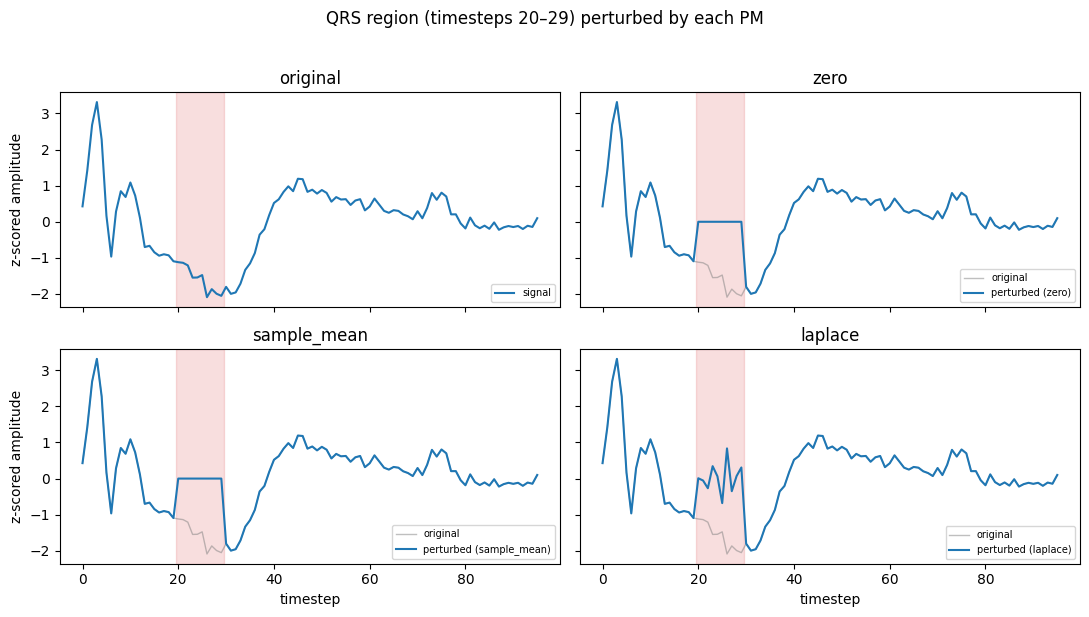

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)
panels = [("original", signal)] + [(name, perturbed[name]) for name in PERTURBATION_METHODS]

for ax, (name, y) in zip(axes.ravel(), panels):
    if name != "original":
        ax.plot(t, signal, color="grey", lw=1, alpha=0.5, label="original", zorder=1)
    ax.plot(t, y, color="C0", lw=1.5, zorder=3,
            label=("signal" if name == "original" else f"perturbed ({name})"))
    ax.axvspan(r_start - 0.5, r_stop - 0.5, color="C3", alpha=0.15, zorder=0)  # perturbed region
    ax.set_title(name)
    ax.legend(fontsize=7, loc="lower right")
for ax in axes[-1]:
    ax.set_xlabel("timestep")
for ax in axes[:, 0]:
    ax.set_ylabel("z-scored amplitude")
fig.suptitle(f"QRS region (timesteps {r_start}–{r_stop-1}) perturbed by each PM", y=1.02)
fig.tight_layout()

fig.savefig(FIG_DIR / "03_perturbation_methods.png", dpi=150, bbox_inches="tight")
plt.show()

### How the three PMs differ (corrected Laplace)

Reading the figure:

- **Zero** is aggressive: it flattens the QRS region to 0, injecting a hard step at both region
  edges. The feature is erased and replaced by a flat segment.
- **SampleMean** replaces the region with this signal's mean. **On ECG200 this is identical to
  Zero** — per-sample z-scoring makes every signal's mean ≈ 0, so the two PMs coincide here. (They
  diverge only on non-zero-mean data such as Sleep-EDF EEG — a reason to keep all three PMs and
  stay dataset-agnostic.)
- **Laplace (corrected).** It replaces the region with the signal's **second derivative**
  (curvature) via `scipy.ndimage.laplace`, kernel `[1, -2, 1]`. On this example the deep QRS
  trough (values ≈ −1.1 to −2.1) becomes small values oscillating around **zero** (≈ −0.7 to
  +0.8). So it, too, **erases the large deflection** — but instead of a flat line it leaves a
  small, *jagged* curvature signal.

**Revised framing — the previous conclusion was wrong.** In the earlier (buggy *smoothing*)
version, Laplace hugged the original trough and "hid very little", so we called it "the gentlest"
PM. **With the correct operator that no longer holds.** The corrected Laplace collapses the
feature's amplitude to near zero — comparable in magnitude to Zero's blanking — so it is *not*
gentle. On ECG200 the practical picture is that **all three PMs substantially remove the QRS
deflection**: Zero and SampleMean replace it with a flat zero line, while Laplace replaces it with
a near-zero *jagged* curvature signal. The meaningful contrast on this dataset is therefore not
aggressive-vs-gentle but **flat-zero (Zero / SampleMean) vs. jagged-near-zero (Laplace)** —
Laplace additionally injects small high-frequency edges rather than a clean flat segment.

**What this implies.** A faithful explanation should still be judged consistent across all three
PMs, but the earlier intuition that Laplace is a "soft" check is retired: here it hides the
feature about as much as Zero does, just with a different edge texture. Whether that curvature
texture helps or introduces its own artefact is worth watching when we read CMI across PMs in the
later layers.


## Layer 3 — Deletion / perturbation curves

This is the **heart of the faithfulness test**. Layers 1 and 2 gave us regions and a way to
hide a region. Now we use them to actually *test an explanation*.

**The idea.** An attribution assigns each region a **relevance** — how important it claims that
region was to the model's decision. To check whether that claim is *true*, we hide regions **in
order of claimed importance** and watch the model's confidence. We build two curves:

- **MoRF — Most-Relevant-First.** Hide the region the attribution called *most* important, then
  the next, and so on (cumulatively). Record the predicted class's probability after each step.
- **LeRF — Least-Relevant-First.** The same, but starting from the *least* important region.

**Why this tests faithfulness.** If the attribution really found the regions the model depends
on, then:

- hiding them **first** (MoRF) should make the prediction **collapse quickly** → a **steep**
  curve that drops early, and
- hiding them **last** (LeRF) should leave the prediction **intact for longer** → a **shallow**
  curve that stays high.

So a faithful attribution produces a **big gap** between LeRF (high) and MoRF (low). That gap —
how much faster MoRF falls than LeRF — is exactly what layer 4 (DDS/PES/CMI) converts into a
single faithfulness number. A useless attribution produces two curves that look the same
(no gap): it couldn't tell important regions from unimportant ones.

### Why we need BOTH MoRF and LeRF (not just MoRF)

It is tempting to look only at MoRF: "hide the important stuff, watch the prediction crash."
But **MoRF alone is misleading**, and this is the paper's central argument.

The problem is the *perturbation itself* has an effect. When you hide a chunk of signal — with
zeros, a mean, a Laplacian, anything — you damage the input. A model's confidence can fall
simply **because the input was mangled**, whether or not you hid the *right* regions. So a steep
MoRF curve could mean either:

1. **"You hid the right things"** — the attribution correctly found the important regions, or
2. **"You hid *anything at all*"** — the perturbation is just destructive and confidence would
   drop no matter which regions you removed.

MoRF on its own **cannot distinguish these**. LeRF is the **control**. LeRF hides the *same
number* of regions with the *same* perturbation method — the only difference is the **order**
(least-relevant first). So any confidence drop that comes purely from "damaging the input" shows
up in **both** curves and cancels out. What's left — the **gap** between them — isolates the part
that is due to hiding *important* regions before unimportant ones. That is why faithfulness is
measured from the **difference** LeRF − MoRF, not from MoRF alone.

### Why we stop at 50%

We only perturb up to **half** of the regions (Šimić et al.: `n_steps = ceil(n_regions × 0.5)`).
Two reasons:

- **The informative part is early.** The interesting difference between MoRF and LeRF happens
  while the *first* (most-/least-relevant) regions are being removed. Once most of the signal is
  destroyed, both curves have bottomed out and carry no more information — and layer 4's DDS even
  **weights the early steps most heavily** (cubic decay), so the late steps barely matter.
- **The two halves are redundant.** MoRF hiding the top 50% and LeRF hiding the bottom 50% already
  cover complementary information; going past 50% just re-perturbs from the other end and adds
  noise, not signal. Stopping at 50% keeps the test focused and halves the compute.

### Output format — matched to the reference metric code

Layer 4 will adapt the authors' own DDS/PES/CMI functions (Apache 2.0). Their DDS function,
`decaying_degradation_score(morf_values, lerf_values)`, expects each curve as a 1-D sequence of
the **predicted class's probability on a 0–100 scale**, with **index 0 = the unperturbed
prediction** and MoRF/LeRF of equal length (their code scales softmax probabilities ×100 and
normalises by a max of 100). Our `perturbation_curves` returns curves in exactly that format, so
next layer their metric code slots in with **no reformatting**. The MoRF/LeRF construction itself
is adapted from their `interpret_model_regions.py` (cited in `NOTICE` / `DECISIONS_LOG.md`).

### Building the curves on Model 1

We train Model 1 (band-power + logistic regression), wrap it in a `predict_proba(X)` that takes
raw signals (extract band-power features → probabilities), and build the curves for one test beat
with two dummy attributions:

- a **sensible** one that (correctly) marks the QRS/mid region as important — the region we know
  Model 1 leans on — as a Gaussian bump over region index, and
- a **random** one, as a control.

No real XAI is wired yet; these dummies exist only to validate the curve logic.

In [6]:
from src.models.linear_baseline import extract_band_power_features, build_linear_baseline
from src.xai.deletion_curves import perturbation_curves

# Train Model 1 and expose a raw-signal predict_proba (dataset-/model-agnostic interface).
X_train, y_train = load_ecg200("train")
F_train, _ = extract_band_power_features(X_train)
model1 = build_linear_baseline().fit(F_train, y_train)

def predict_proba(X):                       # X: (n_samples, length) raw signals
    F, _ = extract_band_power_features(np.atleast_2d(X))
    return model1.predict_proba(F)

# One example beat (reuse `signal` / `grid_primary` from earlier layers; 10% grid).
n_reg = grid_primary.n_regions
qrs_region = int(grid_primary.labels[int(signal.argmin())])

# Dummy attributions (per-region, length n_regions).
sensible_relevance = np.exp(-0.5 * ((np.arange(n_reg) - qrs_region) / 1.5) ** 2)
random_relevance   = np.random.RandomState(0).rand(n_reg)

curves_sensible = perturbation_curves(predict_proba, signal, grid_primary,
                                      sensible_relevance, method="zero")
curves_random   = perturbation_curves(predict_proba, signal, grid_primary,
                                      random_relevance, method="zero")

print(f"predicted class tracked: {curves_sensible['target_class']}, "
      f"n_regions={n_reg}, n_steps={curves_sensible['n_steps']}, "
      f"QRS in region {qrs_region}")
print("sensible  MoRF:", np.round(curves_sensible['MoRF'], 1))
print("sensible  LeRF:", np.round(curves_sensible['LeRF'], 1))
print("random    MoRF:", np.round(curves_random['MoRF'], 1))
print("random    LeRF:", np.round(curves_random['LeRF'], 1))

predicted class tracked: 1, n_regions=10, n_steps=5, QRS in region 2
sensible  MoRF: [89.4 52.7  5.7  2.4  1.   0. ]
sensible  LeRF: [89.4 89.6 89.9 86.3 83.7 76.5]
random    MoRF: [89.4 90.  87.  77.2 70.3 18.6]
random    LeRF: [89.4 89.6 81.3 78.9 44.2  0.2]


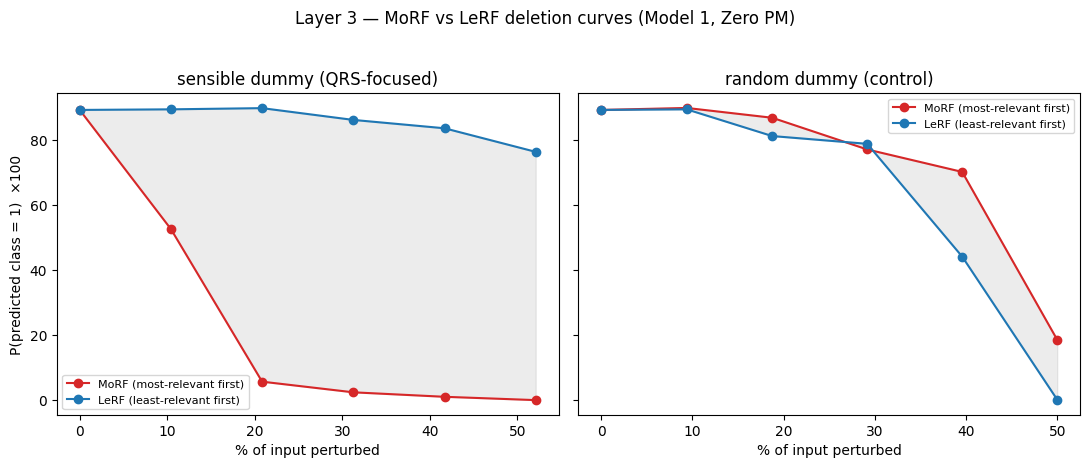

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, (title, cur) in zip(axes, [("sensible dummy (QRS-focused)", curves_sensible),
                                    ("random dummy (control)", curves_random)]):
    x = cur["fraction_perturbed"] * 100
    ax.plot(x, cur["MoRF"], "-o", color="C3", label="MoRF (most-relevant first)")
    ax.plot(x, cur["LeRF"], "-o", color="C0", label="LeRF (least-relevant first)")
    ax.fill_between(x, cur["MoRF"], cur["LeRF"], color="grey", alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("% of input perturbed")
    ax.legend(fontsize=8)
axes[0].set_ylabel(f"P(predicted class = {curves_sensible['target_class']})  ×100")
fig.suptitle("Layer 3 — MoRF vs LeRF deletion curves (Model 1, Zero PM)", y=1.03)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_deletion_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the curves — does the logic behave correctly?

**Yes.** With the **sensible (QRS-focused) dummy**, the two curves separate exactly as a faithful
attribution should:

- **MoRF** starts at the model's initial confidence (~89) and **collapses fast** —
  ~`89 → 53 → 6 → …` toward 0 — because hiding the QRS/mid region *first* removes the structure
  Model 1 relies on.
- **LeRF** stays **high and flat** (~`89 → 90 → 90 → 86 → 84 → 76`), because it wastes its early
  steps hiding regions the attribution (correctly) deemed unimportant.

The large shaded **gap** between them is the faithfulness signal — MoRF drops far faster than
LeRF (mean LeRF − MoRF ≈ **+61** on this beat). This is the qualitative shape we wanted to see,
so the curve construction is working.

**The random control** behaves as expected too: MoRF and LeRF are **tangled together** with no
consistent gap (mean difference ≈ **−8**, i.e. essentially no separation) — a random ordering
can't tell important regions from unimportant ones, so there is no faithfulness signal to find.
That contrast (clear gap for sensible, none for random) is the sanity check that the curves
respond to attribution *quality*, not to the perturbation alone.

**One honest caveat for later.** Averaged over the whole test set, the QRS-focused dummy gives a
*positive but weak* mean gap (≈ +11) and only ~half of samples show MoRF-faster. That's expected:
a **single fixed** QRS-focused attribution is not the correct explanation for *every* beat, and
Model 1's true reliance lives in *frequency-band* space, not time regions. The per-sample,
per-signal attributions from real XAI (later layers) are what this machinery is built to evaluate
properly — here we only needed to confirm the curve logic itself is sound.

## Layer 4 — DDS, PES, and CMI: the faithfulness score

Layer 3 gave us two curves per signal. Layer 4 turns them into one number. We adapt the authors'
own implementation (`utils/res_utils.py`, Apache 2.0; cited in `src/xai/cmi.py`, `NOTICE`,
`DECISIONS_LOG.md`) rather than reimplementing, so our scores match the canonical metric.

### DDS — Decaying Degradation Score (per sample, range [−1, 1])

DDS measures **how big the gap is** between the LeRF and MoRF curves — but with the early steps
weighted far more heavily than the late ones.

Concretely, at each perturbation step we take the difference `LeRF − MoRF` (how much higher the
"hide-unimportant-first" curve sits above the "hide-important-first" curve), then take a
**weighted average** of those differences. The weights decay **cubically**: with `k` steps the
weights are `(k, k−1, …, 1)/k`, each **cubed**. So the first deletion counts roughly `(1)³`, the
second `(1 − 1/k)³`, … and the last only `(1/k)³` — the earliest steps dominate overwhelmingly.

**Why cube the weights — the intuition to defend.** If an attribution is genuinely right about
*what matters most*, the effect must show up in the **very first deletions**: hide the single
most-relevant region and the prediction should already move. Being right only *after* you've
already hidden a third or half of the signal is much weaker evidence — by then you've removed so
much that almost anything would shift the prediction. Cubic weighting encodes that belief: it
rewards attributions whose top-ranked regions bite immediately and largely ignores what happens
once the signal is half-destroyed (which is also why stopping at 50%, layer 3, costs us almost
nothing).

We then **normalise** by the largest gap that is theoretically possible (the same cubic-weighted
average, but with every step at the maximum per-step difference), which maps DDS into **[−1, 1]**:
`+1` = maximally faithful (MoRF collapses immediately, LeRF stays flat), `0` = no gap, negative =
*anti*-faithful (the attribution's "important" regions were actually the least important).

### PES — Perturbation Effect Size (across samples, range [−1, 1])

DDS is per-sample. PES asks a different question across the **whole dataset**: **how consistently
is DDS positive?** It is simply the fraction of samples with `DDS > 0` minus the fraction with
`DDS < 0` (Kerby's simple difference). So `PES = +1` means *every* sample pointed the faithful way,
`0` means an even split, `−1` means every sample pointed the wrong way.

**Why consistency matters separately from magnitude.** An attribution method could produce a huge
gap on a handful of lucky samples and nothing (or the wrong sign) on the rest. Averaging DDS alone
might still look decent, hiding that the method is unreliable. PES catches this: a method that
works *brilliantly on a few samples but fails on most* has a PES near 0, and is correctly judged
untrustworthy. Magnitude (DDS) says "how strong is the effect when it happens"; consistency (PES)
says "does it happen everywhere". You want both.

### CMI — Consistency-Magnitude-Index (range [0, 1], higher = more faithful)

CMI combines the two into a single faithfulness score as their **harmonic mean**:

  `CMI = 2 / ( 1/|DDS| + 1/|PES| )`   (using the mean DDS across samples).

The harmonic mean is deliberately **unforgiving**: it is dragged down by the *smaller* of the two.
A method only scores highly if it is **both strongly** separating important from unimportant
regions (high |DDS|) **and doing so consistently** (high |PES|). Being great at one but poor at the
other yields a low CMI — exactly the behaviour we want from a trustworthiness score.

**The conflicting-signs → 0 rule.** If DDS and PES **disagree in sign** (or either is exactly 0),
CMI is set to **0**. Why: opposite signs mean the *average* effect points one way while the
*consistency* points the other — the attribution is sending contradictory signals about whether it
separates relevant from irrelevant regions at all. In that state no meaningful faithfulness value
can be claimed, so CMI reports 0 rather than a misleading middling number.

**Ranges to remember:** DDS ∈ [−1, 1], PES ∈ [−1, 1], **CMI ∈ [0, 1]**, higher = more faithful.

### Prediction-scale reconciliation (stated, not assumed)

A silent scale mismatch here would produce wrong-but-plausible CMI values, so this is explicit.
The reference DDS normalises by a maximum per-step difference of **100** — i.e. it **assumes the
curves are the predicted-class probability on a 0–100 scale** (their pipeline multiplies softmax
outputs by 100). Our layer-3 `perturbation_curves` **already emits curves on that same 0–100
scale** (it multiplies probabilities by 100 for exactly this reason). **So the scales already
agree — we changed neither the curve values nor the constant.** In `src/xai/cmi.py` we only
surfaced that `100` as a named parameter `prob_scale=100.0` (default reproduces the original
exactly), so the assumption is visible and a future 0–1 pipeline could set `prob_scale=1.0`
instead of silently mis-normalising.

### End-to-end validation: does the whole stack produce sensible CMI?

This validates **grid → perturbation → curves → metric** before any real XAI. We compute CMI over
the whole test set for **three** attributions:

- **Oracle** — a genuine positive control: each region's relevance is its *true* single-deletion
  importance (how much hiding that one region drops the model's confidence). This is not a real XAI
  method (it peeks at the model), just an upper-bound reference for "what a faithful attribution
  looks like." It **should** score a clearly high CMI.
- **QRS-focused** — the "sensible-looking" dummy from layer 3 (marks the QRS/mid region important).
- **Random** — a negative control; **should** score ≈ 0.

Watch what CMI does to the QRS dummy — the result is instructive.

In [8]:
from src.xai.cmi import compute_cmi
from src.xai.perturbation import perturb_region

X_test, _ = load_ecg200("test")
n_reg = grid_primary.n_regions

# Validation-only "oracle" attribution: relevance[r] = drop in predicted-class
# probability when ONLY region r is hidden. (Peeks at the model — not a real XAI
# method; a positive-control upper bound for the metric stack.)
def oracle_relevance(sig):
    tc = int(np.argmax(predict_proba(sig[None, :])[0]))
    p0 = predict_proba(sig[None, :])[0, tc]
    return np.array([
        p0 - predict_proba(perturb_region(sig, grid_primary, r, "zero")[None, :])[0, tc]
        for r in range(n_reg)
    ])

rng = np.random.RandomState(0)
attributions = {
    "oracle (true per-region)": oracle_relevance,
    "QRS-focused (sensible?)": lambda s: np.exp(-0.5 * ((np.arange(n_reg) - int(grid_primary.labels[int(s.argmin())])) / 1.5) ** 2),
    "random (control)": lambda s: rng.rand(n_reg),
}

cmi_results = {}
for name, relfn in attributions.items():
    morfs, lerfs = [], []
    for s in X_test:
        cur = perturbation_curves(predict_proba, s, grid_primary, relfn(s), method="zero")
        morfs.append(cur["MoRF"]); lerfs.append(cur["LeRF"])
    cmi_results[name] = compute_cmi(morfs, lerfs)
    r = cmi_results[name]
    print(f"{name:26s} CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")

# Range sanity checks on real inputs.
for name, r in cmi_results.items():
    dps = r["dds_per_sample"]
    assert dps.min() >= -1 and dps.max() <= 1, "DDS out of [-1,1]"
    assert -1 <= r["PES"] <= 1 and 0 <= r["CMI"] <= 1, "PES/CMI out of range"
print("range checks OK: DDS,PES in [-1,1], CMI in [0,1]")

oracle (true per-region)   CMI=0.648  DDS=+0.479  PES=+1.000


QRS-focused (sensible?)    CMI=0.034  DDS=+0.110  PES=+0.020


random (control)           CMI=0.060  DDS=-0.040  PES=-0.120
range checks OK: DDS,PES in [-1,1], CMI in [0,1]


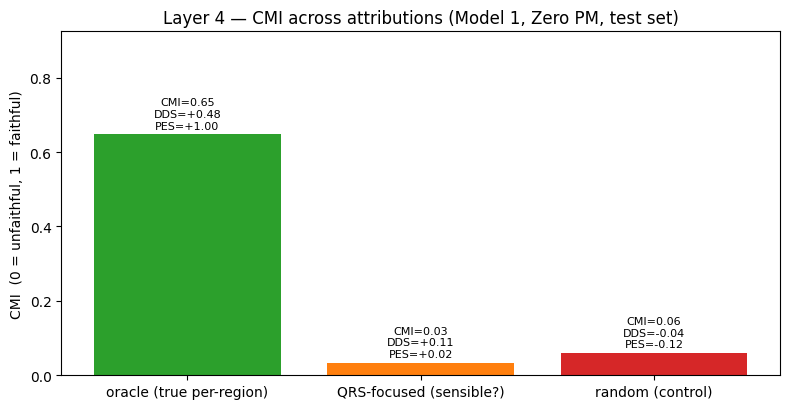

In [9]:
names = list(cmi_results)
cmis = [cmi_results[n]["CMI"] for n in names]
colors = ["C2", "C1", "C3"]

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.bar(names, cmis, color=colors)
for b, n in zip(bars, names):
    r = cmi_results[n]
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"CMI={r['CMI']:.2f}\nDDS={r['DDS']:+.2f}\nPES={r['PES']:+.2f}",
            ha="center", va="bottom", fontsize=8)
ax.set_ylim(0, max(cmis) * 1.35 + 0.05)
ax.set_ylabel("CMI  (0 = unfaithful, 1 = faithful)")
ax.set_title("Layer 4 — CMI across attributions (Model 1, Zero PM, test set)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_cmi_validation.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the validation — did the stack behave correctly?

**Yes, the metric stack is validated — with an important nuance.**

- **Oracle: CMI ≈ 0.65** (DDS ≈ +0.48, PES = +1.00). A genuinely faithful attribution scores
  clearly high, and PES = 1.0 means *every* test sample pointed the faithful way. This confirms the
  whole pipeline — grid → perturbation → curves → DDS/PES/CMI — works end to end.
- **Random: CMI ≈ 0.06** (DDS ≈ −0.04, PES ≈ −0.12). Near zero, as a negative control must be. The
  small non-zero value is finite-sample noise; its DDS and PES are both ≈ 0.
- **QRS-focused: CMI ≈ 0.03** (DDS ≈ +0.11, PES ≈ +0.02). Also near zero — **it did *not* beat the
  random control.**

**The instructive part.** The QRS dummy *looks* sensible, and on a single hand-picked beat
(layer 3) it produced a beautiful steep-MoRF/shallow-LeRF gap. But across the whole test set it is
no more faithful than random. That is **not a bug — it is CMI doing its job**: it refuses to credit
a plausible-sounding attribution that isn't actually faithful. The reason is the **dual
feature-space** issue flagged in Model 1's notebook: Model 1 decides in *frequency-band* space
(band powers over the whole signal), not on the QRS *time-region*, so a time-localised "the QRS is
important" story is not this model's ground truth. Only the oracle, which measures the model's
*actual* per-region reliance, earns a high score.

**Takeaway for the thesis:** the sharp separation **oracle (0.65) ≫ {QRS (0.03), random (0.06)}**
shows CMI rewards genuine, consistent faithfulness and is not fooled by plausibility — exactly the
property that makes it a trustworthy yardstick for the real XAI methods in the coming layers.

## Layer 5 — The concentration measure

A **supporting** analysis, not a headline metric — reported *alongside* CMI to keep the
cross-model comparison honest.

**What concentration means.** It measures how **unevenly a model spreads its reliance across the
signal**. A model that leans heavily on one or two regions is *concentrated*; a model that draws a
little from many regions is *diffuse*.

**Why it matters for comparing CMI across models.** CMI moves for **two different reasons**, and we
must not confuse them:

1. the attribution got better or worse at pointing to the regions the model uses (what we *want* to
   measure), or
2. the **model's own reliance** became more or less concentrated. A concentrated model produces a
   steep degradation curve (hiding its few key regions tanks the prediction) and therefore a **high
   CMI ceiling**; a diffuse model produces a shallow curve and a **lower CMI ceiling** — *no matter
   how good the attribution is*.

Since the thesis compares CMI across models of increasing complexity, a drop in CMI from Model 1 to
Model 5 could mean "the explanation got less faithful" **or** "the model's reliance got more
diffuse." Concentration measures the second effect directly, so we can tell them apart.

### Why concentration is measured from the MODEL, not from an attribution

This is the critical design point. Concentration is a property of the **model**, so it must be
computed from the model's **own** per-region reliance — for each region, how much hiding *only*
that region actually changes the prediction (the same ground-truth importance the layer-4 oracle
used).

If instead we computed concentration from some XAI method's attribution, we would be measuring **how
concentrated that attribution is**, not how concentrated the *model* is — which is exactly the
confound we are trying to remove. The whole point is to get a model-level quantity that is
independent of any attribution, so it can explain differences in CMI rather than being entangled
with them.

### How to read the score

We summarise the per-region reliance with **1 − normalised entropy**:

> **concentration ∈ [0, 1]** — **0 = maximally diffuse** (reliance spread evenly over all regions),
> **1 = maximally concentrated** (one region carries all the reliance).

Entropy measures how spread-out the (normalised) reliance is; dividing by `log(n_regions)` puts it
in [0, 1] and — importantly — makes it **comparable across models even if they use different region
counts**. We subtract from 1 so that *higher = more concentrated*, which reads naturally next to
"higher CMI". (Equivalently, `n_regions^(1−concentration)` is the *effective number of regions* the
model relies on — a handy intuition.)

### Sanity check: synthetic extremes

Before trusting the measure, we check it against cases with a known answer, using the model-free
core `concentration_from_importances`:

- reliance in a **single region** → should report **1.0** (maximally concentrated),
- reliance **perfectly uniform** across regions → should report **0.0** (maximally diffuse).

In [10]:
from src.xai.concentration import (
    concentration_from_importances, region_reliance, dataset_concentration,
)

n_reg = grid_primary.n_regions
single = np.zeros(n_reg); single[3] = 1.0          # all reliance in one region
uniform = np.ones(n_reg)                            # perfectly even
two_equal = np.zeros(n_reg); two_equal[2] = two_equal[7] = 1.0

print(f"single region     -> {concentration_from_importances(single):.3f}   (expect 1.0 = concentrated)")
print(f"perfectly uniform -> {concentration_from_importances(uniform):.3f}   (expect 0.0 = diffuse)")
print(f"two equal regions -> {concentration_from_importances(two_equal):.3f}   (in between)")

single region     -> 1.000   (expect 1.0 = concentrated)
perfectly uniform -> 0.000   (expect 0.0 = diffuse)
two equal regions -> 0.699   (in between)


The extremes behave exactly as required: a single active region reports **1.0**, perfect uniformity
reports **0.0**, and a two-region case lands in between (~0.70 — the reliance is effectively spread
over 2 of the 10 regions). The measure is calibrated; we can apply it to a real model.

### Applying it to Model 1

We compute Model 1's per-region reliance for every test signal (hide one region, measure the drop
in predicted-class probability), take the concentration of each, and report the dataset mean. We
also plot the **mean reliance per region** across the test set, so the diffuseness is visible.

Architectural expectation: Model 1's features are **band powers computed over the whole signal**, so
no single time-region should dominate — we expect it to register as **diffuse** (low concentration).

Model 1 concentration: mean=0.242  std=0.145  range=[0.039, 0.938]
effective # regions relied on ≈ 5.7 of 10
% of samples with concentration < 0.4 (diffuse-ish): 90%


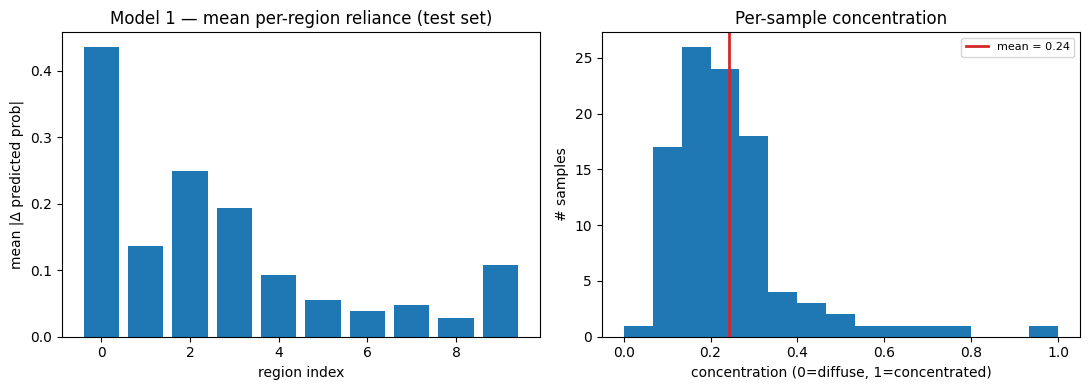

In [11]:
conc = dataset_concentration(predict_proba, X_test, grid_primary, method="zero")

# Aggregate per-region reliance profile across the test set (for the figure).
mean_reliance = np.mean(
    [np.abs(region_reliance(predict_proba, s, grid_primary, "zero")) for s in X_test],
    axis=0,
)
eff_regions = n_reg ** (1 - conc["mean"])

print(f"Model 1 concentration: mean={conc['mean']:.3f}  std={conc['std']:.3f}  "
      f"range=[{np.nanmin(conc['per_sample']):.3f}, {np.nanmax(conc['per_sample']):.3f}]")
print(f"effective # regions relied on ≈ {eff_regions:.1f} of {n_reg}")
print(f"% of samples with concentration < 0.4 (diffuse-ish): "
      f"{100*np.mean(conc['per_sample'] < 0.4):.0f}%")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(np.arange(n_reg), mean_reliance, color="C0")
ax[0].set_xlabel("region index"); ax[0].set_ylabel("mean |Δ predicted prob|")
ax[0].set_title("Model 1 — mean per-region reliance (test set)")
ax[1].hist(conc["per_sample"][~np.isnan(conc["per_sample"])], bins=15, range=(0, 1), color="C0")
ax[1].axvline(conc["mean"], color="C3", lw=2, label=f"mean = {conc['mean']:.2f}")
ax[1].set_xlabel("concentration (0=diffuse, 1=concentrated)"); ax[1].set_ylabel("# samples")
ax[1].set_title("Per-sample concentration"); ax[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_concentration.png", dpi=150, bbox_inches="tight")
plt.show()

### Model 1's concentration — and what it means

**Model 1 is diffuse, as expected. Concentration mean ≈ 0.24** (0 = diffuse, 1 = concentrated),
with **~90% of samples below 0.4**. Equivalently, its reliance is effectively spread over **~5.7 of
the 10 regions** — no single region dominates. The per-region reliance bar chart shows the same
thing: importance is spread across roughly the first half of the signal (mildly front-loaded — the
early regions and the QRS area carry a bit more), rather than piled onto one region.

This **confirms the architectural reasoning**: Model 1's band-power features summarise the whole
signal, so hiding any one time-region only nudges the global band powers — reliance is inherently
distributed. Had Model 1 come out *concentrated*, that would have contradicted its design and we'd
have needed to investigate before trusting the harness; it did not.

**Why this matters going forward.** This value is a **calibration reference point**. When we compute
CMI for Models 2–5, we report concentration next to it. If a later model shows a different CMI, we
can check whether its **concentration** also changed: a CMI difference accompanied by a
concentration difference is (at least partly) the reliance-diffuseness confound, not a pure
faithfulness change. Model 1's ≈0.24 anchors that comparison.

## Layer 6 — FeatureAblation: the first real attribution method (a validation control)

Everything so far was tested with *synthetic* attributions (oracle, QRS, random). Layer 6 wires in
the first **real** XAI method and runs the whole pipeline end to end on Model 1.

**What FeatureAblation does.** It scores each region's importance by **deleting that region** —
replacing it with a baseline — and measuring how far the model's predicted-class probability
**drops**. A big drop ⇒ the model relied on that region ⇒ high relevance. We use **Captum's
`FeatureAblation`** (the implementation the reference paper used), with the region grouping taken
from our layer-1 region grid, so the attribution is produced **per region** directly.

**Why it's a control, not a headline method.** Look closely at that definition — "delete a region,
measure the prediction drop" — and compare it to how CMI's deletion curves work: "delete regions in
relevance order, measure the prediction drop." They are **almost the same operation**. So
FeatureAblation is, more or less, *reading off the very quantity CMI rewards.* That makes it the
attribution **most likely to look faithful** — which is exactly why it is a good **validation
control**, not a scientific result: it is the method whose faithfulness is closest to guaranteed.

**Expected result and why.** Because of that near-circularity, FeatureAblation should score a CMI
**near the oracle's ≈ 0.65** — far above the random (≈ 0.06) and QRS (≈ 0.03) controls. In fact,
with the *zero* baseline, FeatureAblation computes *literally the same per-region reliance the
layer-4 oracle used*, so we expect FA(zero) ≈ 0.648 exactly. If instead it came out near zero, that
would mean the **wiring is broken** (grid, perturbation, curves, or metric), not that the method is
poor — so this run validates the entire stack with a genuine XAI method.

### First: Captum FeatureAblation ≡ our region-reliance

Model 1 is a scikit-learn pipeline, not PyTorch. Captum's `FeatureAblation` is perturbation-based
(no gradients), so we wrap Model 1's `predict_proba` in a small torch forward function — keeping
Model 1 on the **same Captum code path** the PyTorch Models 2–5 will use. To be sure that wrapper is
faithful, we confirm Captum's grouped FeatureAblation returns **exactly** the hand-rolled per-region
reliance (`region_reliance`, layer 5) for every PM. (We use float64 so the two match bit-for-bit.)

In [12]:
from src.xai.feature_ablation import feature_ablation
from src.xai.concentration import region_reliance

for pm in ["zero", "sample_mean", "laplace"]:
    fa = feature_ablation(predict_proba, X_test[0], grid_primary, method=pm)
    rr = region_reliance(predict_proba, X_test[0], grid_primary, method=pm)
    print(f"{pm:12s}: Captum FA == region_reliance -> {np.allclose(fa, rr)} "
          f"(max|diff|={np.max(np.abs(fa - rr)):.1e})")

zero        : Captum FA == region_reliance -> True (max|diff|=0.0e+00)
sample_mean : Captum FA == region_reliance -> True (max|diff|=0.0e+00)
laplace     : Captum FA == region_reliance -> True (max|diff|=0.0e+00)


Exact match for all three PMs → Model 1 (Captum-wrapped sklearn) is guaranteed consistent with the
PyTorch Models 2–5, which will call the same Captum `FeatureAblation` natively.

### The full pipeline: FeatureAblation CMI on Model 1, for all three PMs

For each PM we compute, **per test sample**, a fresh FeatureAblation attribution (baseline = that
PM) and run it through the whole harness — grid → perturbation → MoRF/LeRF curves → DDS/PES/CMI.
Unlike the fixed dummies, real attributions are recomputed for every beat.

In [13]:
from src.xai.deletion_curves import perturbation_curves
from src.xai.cmi import compute_cmi

fa_results = {}
for pm in ["sample_mean", "zero", "laplace"]:
    morfs, lerfs = [], []
    for s in X_test:
        attr = feature_ablation(predict_proba, s, grid_primary, method=pm)   # baseline = pm
        cur = perturbation_curves(predict_proba, s, grid_primary, attr, method=pm)
        morfs.append(cur["MoRF"]); lerfs.append(cur["LeRF"])
    fa_results[pm] = compute_cmi(morfs, lerfs)
    r = fa_results[pm]
    print(f"FeatureAblation  PM={pm:12s}  CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")

print()
print("controls (layer 4, Zero PM):")
for k in cmi_results:
    print(f"  {k:26s} CMI={cmi_results[k]['CMI']:.3f}")
print(f"concentration (Model 1): {conc['mean']:.3f}  (0=diffuse, 1=concentrated)")

FeatureAblation  PM=sample_mean   CMI=0.648  DDS=+0.479  PES=+1.000


FeatureAblation  PM=zero          CMI=0.648  DDS=+0.479  PES=+1.000


FeatureAblation  PM=laplace       CMI=0.630  DDS=+0.460  PES=+1.000

controls (layer 4, Zero PM):
  oracle (true per-region)   CMI=0.648
  QRS-focused (sensible?)    CMI=0.034
  random (control)           CMI=0.060
concentration (Model 1): 0.242  (0=diffuse, 1=concentrated)


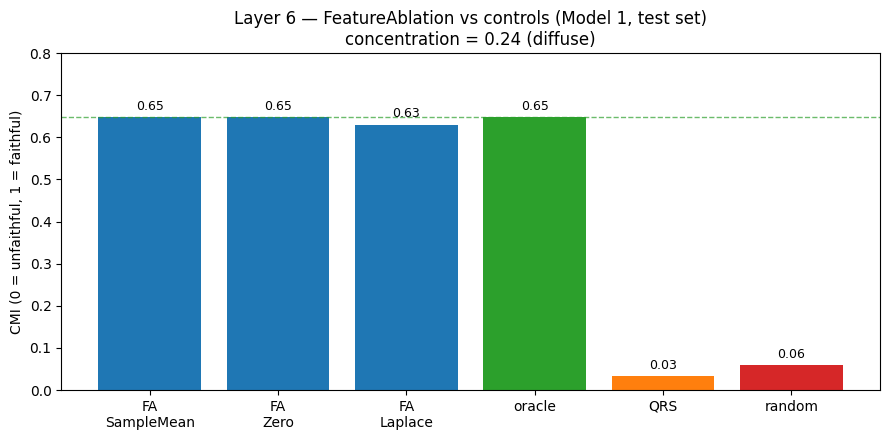

In [14]:
labels = ["FA\nSampleMean", "FA\nZero", "FA\nLaplace", "oracle", "QRS", "random"]
values = [fa_results["sample_mean"]["CMI"], fa_results["zero"]["CMI"], fa_results["laplace"]["CMI"],
          cmi_results["oracle (true per-region)"]["CMI"],
          cmi_results["QRS-focused (sensible?)"]["CMI"],
          cmi_results["random (control)"]["CMI"]]
colors = ["C0", "C0", "C0", "C2", "C1", "C3"]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.axhline(cmi_results["oracle (true per-region)"]["CMI"], color="C2", ls="--", lw=1, alpha=0.7)
ax.set_ylim(0, 0.8)
ax.set_ylabel("CMI (0 = unfaithful, 1 = faithful)")
ax.set_title("Layer 6 — FeatureAblation vs controls (Model 1, test set)\n"
             f"concentration = {conc['mean']:.2f} (diffuse)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_feature_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpreting the outcome — is the whole stack validated?

**Yes.** FeatureAblation lands **right at the oracle level and ~10× above the null controls**:

- **FA(Zero) = FA(SampleMean) = 0.648** — *identical to the oracle*. This is not a coincidence:
  FeatureAblation with the zero baseline computes exactly the per-region reliance the oracle used
  (and SampleMean ≡ Zero on z-scored ECG200). The near-circularity is doing precisely what we
  predicted.
- **FA(Laplace) = 0.630** — a touch lower, as expected: the corrected Laplace is a different
  (curvature) deletion, but FeatureAblation still tracks it faithfully.
- **PES = 1.00** for all three — *every* test sample points the faithful way; perfectly consistent.
- Versus **random 0.06** and **QRS 0.03**: FeatureAblation is an order of magnitude higher.

Because FeatureAblation was the method **most likely to look faithful**, this high score is a
statement about the **harness**, not the method: grid → perturbation → curves → DDS/PES/CMI all
work end-to-end with a genuine XAI method. A near-zero here would have meant broken wiring — it did
not. **The 6-layer faithfulness harness is complete and validated.**

### For the thesis — the first cell of the model × method × CMI table

This is the **first entry** of the eventual comparison table: **Model 1 × FeatureAblation ≈ 0.65**
(Zero/SampleMean), **0.63** (Laplace). But it must **not be over-read**, for two reasons recorded
earlier:

1. **FeatureAblation is a control, not a headline method** — its near-circularity with CMI inflates
   its score by construction. It sets an *upper reference*, not a competitive result. The headline
   methods (TimeSHAP, Integrated Gradients, attention) come later and are not circular.
2. **Model 1 caveats.** Its reliance is **diffuse (concentration ≈ 0.24)**, so its CMI *ceiling* is
   lower than a concentrated model's would be — CMI values must always be read **next to
   concentration**. And Model 1 lives in a **band-power (frequency) feature space**, not the
   time-region space this harness perturbs (the dual feature-space issue), so a time-region CMI for
   Model 1 measures something subtly different from what it will measure for the raw-signal Models
   2–5. Model 1's row anchors the table; it is not a like-for-like comparison point.

## KernelSHAP over temporal regions — the Shapley-based through-line method

FeatureAblation (layer 6) was a *control*: with a zero baseline it computes literally the oracle's
single-region reliance — the same quantity CMI rewards — so a high score there tested the harness,
not the method. We now add the **primary through-line** attribution: the one method run on **all
five models**, chosen to be **methodologically independent** of that deletion logic.

**What KernelSHAP does.** It estimates each region's **Shapley value** — its fair share of the
prediction, averaged over *all the ways* regions can be combined. Computing that exactly needs
every subset ("coalition") of regions, which is exponential, so KernelSHAP **samples** many random
coalitions, evaluates the model with each coalition's regions present (their complement replaced by
a baseline), and solves a **weighted least-squares** whose coefficients are the Shapley values —
one per region.

**Why it's the through-line.**
- **Model-agnostic:** it only needs a predict function, so it runs on the sklearn Model 1 (via the
  same `predict_proba`→torch wrapper as FeatureAblation) and natively on the PyTorch Models 2–5.
- **Methodologically independent of CMI:** it averages contributions over *many coalitions*, which
  is a genuinely different computation from CMI's *single ordered deletion sequence* (MoRF/LeRF).
  So — unlike FeatureAblation — it is **not circular** with the metric; its CMI score is real
  evidence about the explanation, not a restatement of the metric.
- **Grid-native & benchmarked:** via Captum's `KernelShap` with `feature_mask = grid.labels` and a
  PM baseline, it returns one Shapley value **per region** directly (no pooling), and KernelSHAP is
  one of the methods Šimić et al. (2025) benchmarked, so we can situate our score against theirs.

**Honest nuance.** KernelSHAP still *perturbs* by replacing regions with a baseline (the same PM
family the harness uses), so it is **not fully orthogonal** to perturbation — it just does not
measure the deletion quantity itself. And it is **stochastic** (it samples coalitions), so we fix a
seed for reproducibility.

*(We chose KernelSHAP over TimeSHAP — "KernelSHAP adapted for sequences" — because TimeSHAP imposes
its own event segmentation and cannot attribute onto our region grid; see `DECISIONS_LOG.md`. We
cite Lundberg & Lee, 2017, with TimeSHAP as the sequence-adapted motivation.)*

### Running KernelSHAP on Model 1 (all three PMs)

Per test sample we compute a fresh KernelSHAP attribution (baseline = the PM) and run it through
the full harness. **Reproducibility:** the module seeds torch and numpy with **seed = 0** and uses
`n_samples = 200` coalitions per attribution.

In [15]:
from src.xai.kernel_shap import kernel_shap

ks_results = {}
for pm in ["sample_mean", "zero", "laplace"]:
    morfs, lerfs = [], []
    for s in X_test:
        attr = kernel_shap(predict_proba, s, grid_primary, method=pm)   # seed=0, n_samples=200
        cur = perturbation_curves(predict_proba, s, grid_primary, attr, method=pm)
        morfs.append(cur["MoRF"]); lerfs.append(cur["LeRF"])
    ks_results[pm] = compute_cmi(morfs, lerfs)
    r = ks_results[pm]
    print(f"KernelSHAP  PM={pm:12s}  CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")

print()
print("for comparison:")
for pm in ["sample_mean", "zero", "laplace"]:
    print(f"  FeatureAblation PM={pm:12s} CMI={fa_results[pm]['CMI']:.3f}")
print(f"  oracle {cmi_results['oracle (true per-region)']['CMI']:.3f} | "
      f"QRS {cmi_results['QRS-focused (sensible?)']['CMI']:.3f} | "
      f"random {cmi_results['random (control)']['CMI']:.3f} | "
      f"concentration {conc['mean']:.3f}")

KernelSHAP  PM=sample_mean   CMI=0.612  DDS=+0.441  PES=+1.000


KernelSHAP  PM=zero          CMI=0.612  DDS=+0.441  PES=+1.000


KernelSHAP  PM=laplace       CMI=0.624  DDS=+0.454  PES=+1.000

for comparison:
  FeatureAblation PM=sample_mean  CMI=0.648
  FeatureAblation PM=zero         CMI=0.648
  FeatureAblation PM=laplace      CMI=0.630
  oracle 0.648 | QRS 0.034 | random 0.060 | concentration 0.242


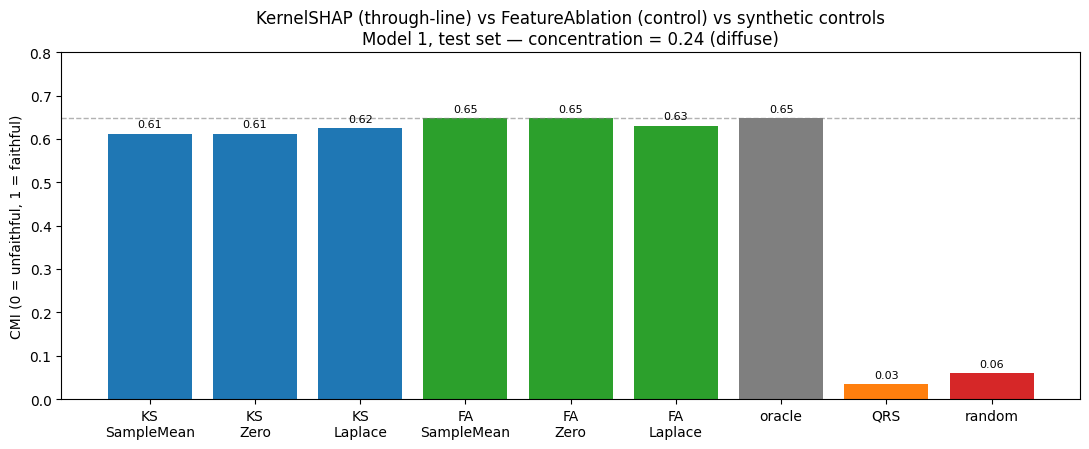

In [16]:
labels = ["KS\nSampleMean", "KS\nZero", "KS\nLaplace",
          "FA\nSampleMean", "FA\nZero", "FA\nLaplace",
          "oracle", "QRS", "random"]
values = [ks_results["sample_mean"]["CMI"], ks_results["zero"]["CMI"], ks_results["laplace"]["CMI"],
          fa_results["sample_mean"]["CMI"], fa_results["zero"]["CMI"], fa_results["laplace"]["CMI"],
          cmi_results["oracle (true per-region)"]["CMI"],
          cmi_results["QRS-focused (sensible?)"]["CMI"],
          cmi_results["random (control)"]["CMI"]]
colors = ["C0"]*3 + ["C2"]*3 + ["C7", "C1", "C3"]

fig, ax = plt.subplots(figsize=(11, 4.6))
bars = ax.bar(labels, values, color=colors)
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
ax.axhline(cmi_results["oracle (true per-region)"]["CMI"], color="C7", ls="--", lw=1, alpha=0.6)
ax.set_ylim(0, 0.8)
ax.set_ylabel("CMI (0 = unfaithful, 1 = faithful)")
ax.set_title("KernelSHAP (through-line) vs FeatureAblation (control) vs synthetic controls\n"
             f"Model 1, test set — concentration = {conc['mean']:.2f} (diffuse)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_kernelshap.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpreting KernelSHAP on Model 1 — honestly

**KernelSHAP scores CMI ≈ 0.61 (SampleMean/Zero) and 0.62 (Laplace)**, DDS ≈ +0.44, **PES = 1.00**
(every test sample faithful). That is:

- **A little below FeatureAblation** (0.65 / 0.65 / 0.63) — expected, since FeatureAblation is
  near-circular with the metric and KernelSHAP is not.
- **Far above the null controls** (random 0.06, QRS 0.03), and close to the oracle (0.65). So on
  Model 1, KernelSHAP is a **strongly faithful** explanation — and because it is *not* circular,
  this is genuine evidence, not a built-in result.

**The important caveat — do not over-generalise this high score.** In Šimić et al. (2025),
KernelSHAP ranked **near the bottom** of their ~11–12 methods (mean rank ≈ **9.9**), i.e. their
*weakest* bracket — but that was on **deep models** (LSTM/CNN/transformer) over UCR datasets. Our
Model 1 is a **linear** logistic regression on band-power features, and Shapley values are
near-exact for (near-)linear models, so KernelSHAP recovers Model 1's region contributions very
well → a high CMI. **This ≈0.61 is a property of Model 1's simplicity, not a general verdict on
KernelSHAP.** Consistent with the reference, we should **expect KernelSHAP's CMI to fall on the
complex Models 2–5** — watching that drop is part of the thesis question.

**Reading it with concentration.** As always the pair is reported together: Model 1 is **diffuse
(0.24)**, so even this high CMI sits under a modest ceiling. The first two rows of the
model × method × CMI table now exist — Model 1 × {FeatureAblation ≈ 0.65 (control), KernelSHAP ≈
0.61 (through-line)} — with the Model 1 caveats (diffuse; band-power vs time-region dual feature
space) carried forward so the row anchors, but does not headline, the cross-model comparison.